# Naive M-CaStLe Demonstration

This notebook demonstrates the **Naive M-CaStLe** baseline method, which combines:

1. **Independent U-CaStLe** — run univariate CaStLe separately on each variable's 2D spatial field to learn per-variable spatial stencils.
2. **Non-spatial PC/PCMCI** — spatially aggregate each variable (spatial mean) and run PC on the resulting multivariate timeseries to identify inter-variable causal links.
3. **Combination** — assemble a multivariate stencil by placing each variable's spatial stencil on the diagonal blocks, and connecting variable center-nodes wherever the non-spatial graph found a link.

This is a competitive baseline positioned between pure spatial single-variable methods and fully-coupled M-CaStLe. It cannot recover inter-variable links that involve off-center spatial positions (e.g., the northeast neighbor of variable A affecting the center of variable B), but it correctly recovers intra-variable spatial structure and variable-level inter-variable links.

---

**Experiments:**
- **Experiment 1** — 2 variables, 4×4 grid, 0.5 link density (~18 links)
- **Experiment 2** — 4 variables, 4×4 grid, 15 explicit links

## Setup

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tigramite.independence_tests.parcorr import ParCorr

sys.path.append("../src")
import spatiotemporal_SCM_data_generator as dg
import mcastle_utils as mcastle
import causal_graph_metrics as gm
from naive_mcastle_utils import naive_mv_CaStLe_PC

In [2]:
def print_f1_report(label, true_graph, discovered_graph):
    """Print a concise F1/precision/recall/MCC/FDR report and return the scores."""
    TP, FP, FN, TN = gm.get_confusion_matrix(true_graph, discovered_graph)
    F1, P, R, *_ = gm.F1_score(TP=TP, FP=FP, FN=FN, TN=TN)
    MCC = gm.matthews_correlation_coefficient(TP=TP, FP=FP, FN=FN, TN=TN)
    FDR = gm.false_discovery_rate(FP, TP)
    print(f"{label}")
    print(f"  F1={F1:.3f}  Precision={P:.3f}  Recall={R:.3f}  MCC={MCC:.3f}  FDR={FDR:.3f}")
    print(f"  TP={TP}  FP={FP}  FN={FN}  TN={TN}")
    return F1, P, R, MCC, FDR


def plot_intermediate_steps(true_stencil, true_vals, naive_results,
                             var_names=None, title_prefix=""):
    """
    Two-row figure showing the intermediate steps of Naive M-CaStLe.

    Row 0 - Ground Truth:
        Per-variable intra-stencil (diagonal block) for each var  |  True reaction graph

    Row 1 - Discovered:
        U-CaStLe stencil per variable (Step 1)  |  Non-spatial PC reaction graph (Step 2)

    The non-spatial PC reaction graph (bottom-right) is directly comparable to the true
    reaction graph (top-right): found inter-variable links become center-to-center edges
    in the combined stencil.
    """
    n_vars = true_stencil.shape[0] // 9
    vnames = var_names or [chr(65 + k) for k in range(n_vars)]

    ucastle_res = naive_results["ucastle_results"]
    ns_res      = naive_results["non_spatial_results"]
    ns_graph    = ns_res["graph"]
    ns_val      = ns_res["val_matrix"]

    true_rx, true_rx_val, _, _ = mcastle.analyze_stencil_graphs(true_stencil, true_vals)

    n_cols = n_vars + 1
    fig, axs = plt.subplots(2, n_cols, figsize=(6 * n_cols, 11))
    if n_vars == 1:
        axs = axs.reshape(2, 1)

    # Row 0: ground truth per-variable diagonal blocks + true reaction graph
    for k in range(n_vars):
        bs, be = 9 * k, 9 * k + 9
        blk   = true_stencil[bs:be, bs:be, :]
        blk_v = true_vals[bs:be, bs:be, :]
        mcastle.plot_stencil_graph(blk, blk_v, directional_var_names=True,
                                    ax=axs[0, k], fig=fig)
        axs[0, k].set_title(f"Truth: Var {vnames[k]} spatial stencil")
    mcastle.plot_reaction_graph(true_rx, true_rx_val, var_names=vnames,
                                 ax=axs[0, n_vars], fig=fig)
    axs[0, n_vars].set_title("Truth: Reaction Graph\n(inter-variable causal links)")

    # Row 1: U-CaStLe per variable + non-spatial PC reaction graph
    for k in range(n_vars):
        u_g = ucastle_res[k]["graph"]
        u_v = ucastle_res[k]["val_matrix"]
        bs, be = 9 * k, 9 * k + 9
        tp, fp, fn, tn = gm.get_confusion_matrix(true_stencil[bs:be, bs:be, :], u_g)
        f1, *_ = gm.F1_score(TP=tp, FP=fp, FN=fn, TN=tn)
        mcastle.plot_stencil_graph(u_g, u_v, directional_var_names=True,
                                    ax=axs[1, k], fig=fig)
        axs[1, k].set_title(f"Step 1 - U-CaStLe: Var {vnames[k]}  (F1={f1:.2f})")
    mcastle.plot_reaction_graph(ns_graph, ns_val, var_names=vnames,
                                 ax=axs[1, n_vars], fig=fig)
    axs[1, n_vars].set_title(
        "Step 2 - Non-Spatial PC: Reaction Graph\n"
        "(compare to truth above;\n"
        "found links -> inter-var center-to-center edges)"
    )

    fig.suptitle(f"{title_prefix}Naive M-CaStLe - Intermediate Steps",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig, axs


def plot_final_comparison(true_stencil, true_vals, disc_stencil, disc_vals,
                           var_names=None, f1_stencil=None, f1_rx=None,
                           title_prefix=""):
    """
    2x2 comparison: ground truth (left) vs Naive M-CaStLe Step 3 output (right).

    Row 0: Full multivariate stencil
    Row 1: Reaction graph
    """
    n_vars = true_stencil.shape[0] // 9
    vnames = var_names or [chr(65 + k) for k in range(n_vars)]

    true_rx, true_rx_val, _, _ = mcastle.analyze_stencil_graphs(true_stencil, true_vals)
    disc_rx, disc_rx_val, _, _ = mcastle.analyze_stencil_graphs(disc_stencil, disc_vals)

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    mcastle.plot_stencil_graph(true_stencil, true_vals, var_names=vnames,
                                ax=axs[0, 0], fig=fig)
    axs[0, 0].set_title("Truth: Full Multivariate Stencil")

    f1s_str = f"  (F1={f1_stencil:.3f})" if f1_stencil is not None else ""
    mcastle.plot_stencil_graph(disc_stencil, disc_vals, var_names=vnames,
                                ax=axs[0, 1], fig=fig)
    axs[0, 1].set_title(f"Step 3 - Naive M-CaStLe: Full Stencil{f1s_str}")

    mcastle.plot_reaction_graph(true_rx, true_rx_val, var_names=vnames,
                                 ax=axs[1, 0], fig=fig)
    axs[1, 0].set_title("Truth: Reaction Graph")

    f1r_str = f"  (F1={f1_rx:.3f})" if f1_rx is not None else ""
    mcastle.plot_reaction_graph(disc_rx, disc_rx_val, var_names=vnames,
                                 ax=axs[1, 1], fig=fig)
    axs[1, 1].set_title(f"Naive M-CaStLe: Reaction Graph{f1r_str}")

    fig.suptitle(
        f"{title_prefix}Naive M-CaStLe - Final Result (Step 3) vs Ground Truth",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    return fig, axs

---
## Simple Example: 2 Variables, 3 Links (Ideal Case)

The simplest possible multivariate system to verify the method works correctly.

**Three manually defined links:**
- **Link 1** — `var_A self-dep`: A(center, t-1) → A(center, t) &nbsp;&nbsp; *(intra-variable; recovered by U-CaStLe on A)*
- **Link 2** — `var_B self-dep`: B(center, t-1) → B(center, t) &nbsp;&nbsp; *(intra-variable; recovered by U-CaStLe on B)*
- **Link 3** — `var_A → var_B coupling`: A(center, t-1) → B(center, t) &nbsp;&nbsp; *(inter-variable, center-to-center; recovered by non-spatial PC)*

All three links are center-to-center and are fully recoverable by naive M-CaStLe, so we expect F1 ≈ 1.0 here.

In [ ]:
# Manually define 3 center-to-center links — all recoverable by naive M-CaStLe
spatial_coefs0 = dg.get_empty_coefficient_matrix(n_variables=2)
spatial_coefs0[0, 1, 1][0] = 0.40  # Link 1: A(center, t-1) -> A(center, t)
spatial_coefs0[1, 1, 1][1] = 0.30  # Link 2: B(center, t-1) -> B(center, t)
spatial_coefs0[1, 1, 1][0] = 0.35  # Link 3: A(center, t-1) -> B(center, t)

data0 = dg.generate_dataset(T=500, grid_size=4, spatial_coefs=spatial_coefs0, random_seed=0)
print(f"data0 shape: {data0.shape}")

# Ground truth stencil
true_stencil0, true_vals0 = mcastle.get_stencil_graph_from_coefficients(spatial_coefs0)
print(f"Ground truth links: {int(np.sum(true_stencil0 != ''))}")
print(f"  Link 1 graph[4,  4,  1] = {true_stencil0[4,  4,  1]!r}")    # A center self-dep
print(f"  Link 2 graph[13, 13, 1] = {true_stencil0[13, 13, 1]!r}")    # B center self-dep
print(f"  Link 3 graph[4,  13, 1] = {true_stencil0[4,  13, 1]!r}")    # A center -> B center

fig, ax = mcastle.plot_stencil_graph(true_stencil0, true_vals0, var_names=["A", "B"])
ax.set_title("Simple Example — Ground-Truth Stencil (3 links)")
plt.show()

In [29]:
# --- Run Naive M-CaStLe ---
ci_test0 = ParCorr(significance="analytic")

naive_results0 = naive_mv_CaStLe_PC(
    data=data0,
    cond_ind_test=ci_test0,
    pc_alpha=0.1,
    graph_p_threshold=0.00,
    min_tau=1,
    rows_inverted=True,
    cd_function="run_pcalg",
    fdr_method=None,
    dependencies_wrap=True,
    allow_center_directed_links=True,
    verbose=1,
)

disc_stencil0 = naive_results0["graph"]
disc_vals0    = naive_results0["val_matrix"]

print()
print("=" * 50)
f1_full0, *_  = print_f1_report("Full stencil", true_stencil0, disc_stencil0)
true_rx0, true_rx_val0, _, _ = mcastle.analyze_stencil_graphs(true_stencil0, true_vals0)
disc_rx0, disc_rx_val0, _, _ = mcastle.analyze_stencil_graphs(disc_stencil0, disc_vals0)
f1_rx0, *_    = print_f1_report("Reaction graph", true_rx0, disc_rx0)
print("=" * 50)

Running U-CaStLe on variable 0 of 2...
Running U-CaStLe on variable 1 of 2...
Running non-spatial run_pcalg on spatially aggregated data (shape (500, 2))...
Naive multivariate stencil assembled.

Full stencil
  F1=0.500  Precision=0.500  Recall=0.500  MCC=0.497  FDR=0.500
  TP=2  FP=2  FN=2  TN=642
Reaction graph
  F1=0.857  Precision=1.000  Recall=0.750  MCC=0.775  FDR=0.000
  TP=3  FP=0  FN=1  TN=4


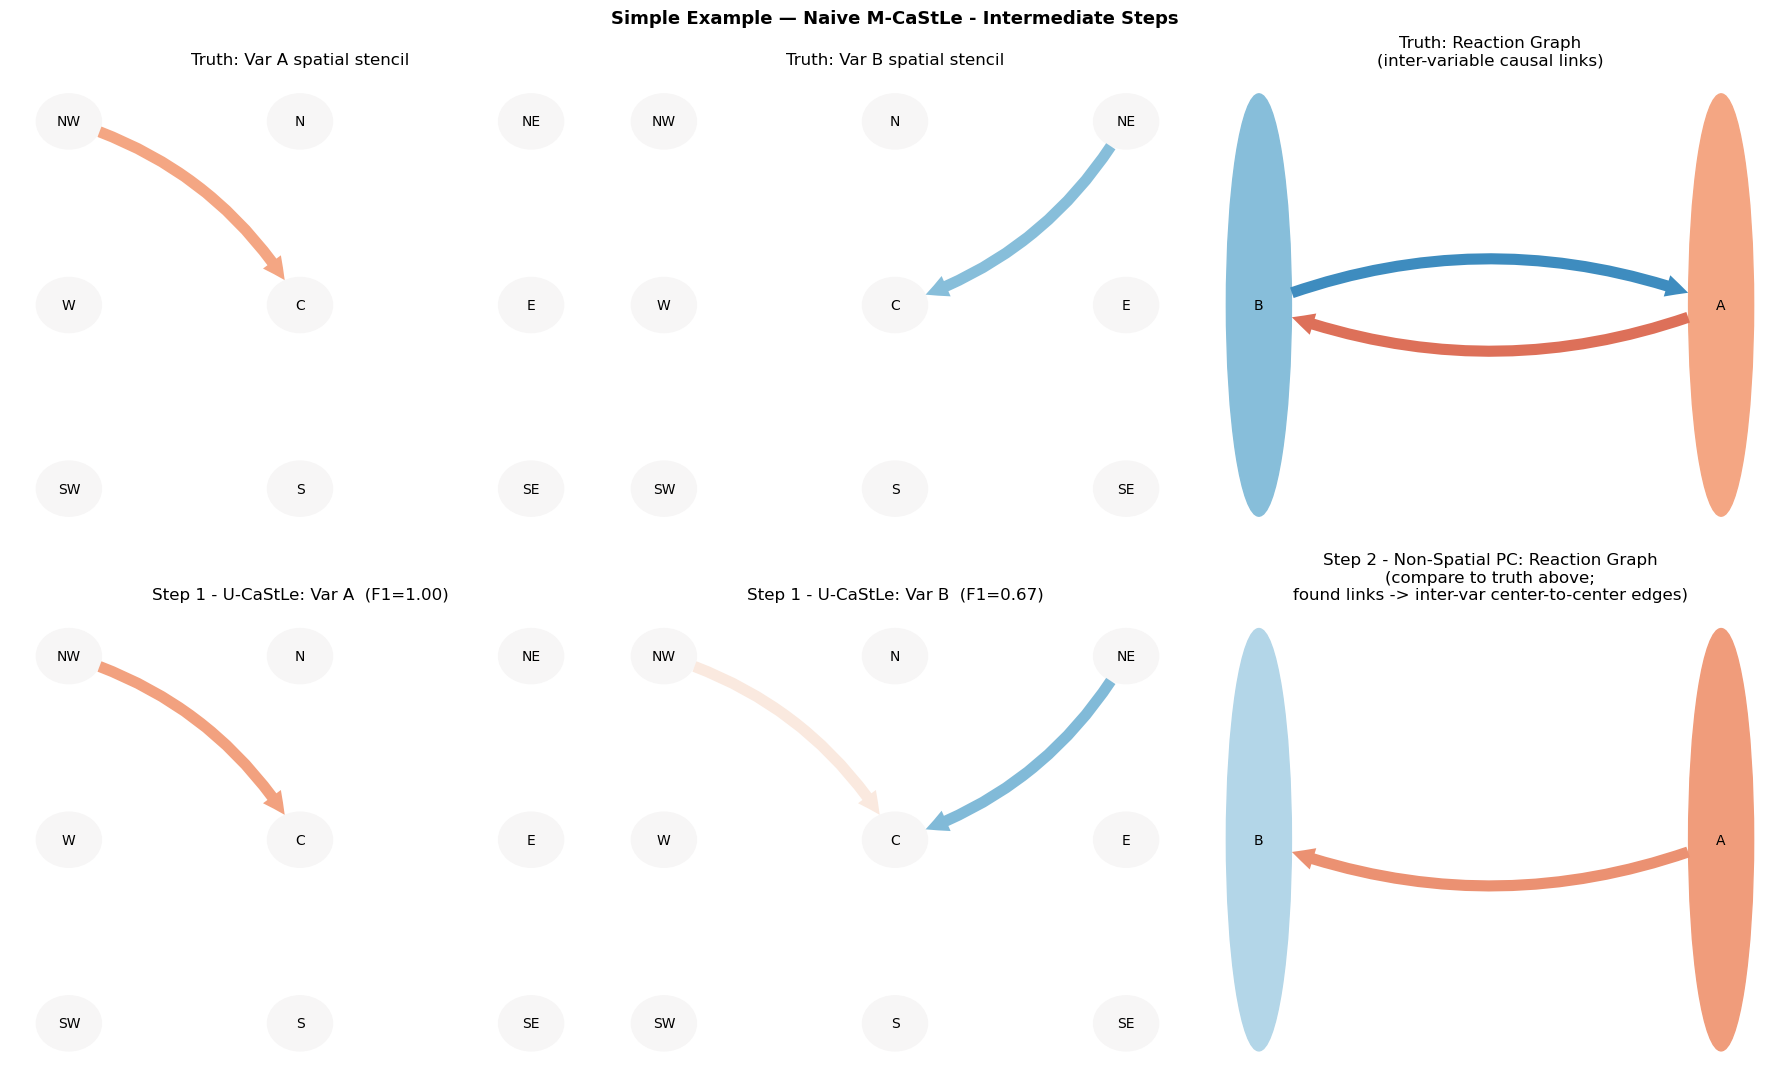

In [30]:
plot_intermediate_steps(
    true_stencil0, true_vals0,
    naive_results0,
    var_names=["A", "B"],
    title_prefix="Simple Example — ",
)
plt.show()

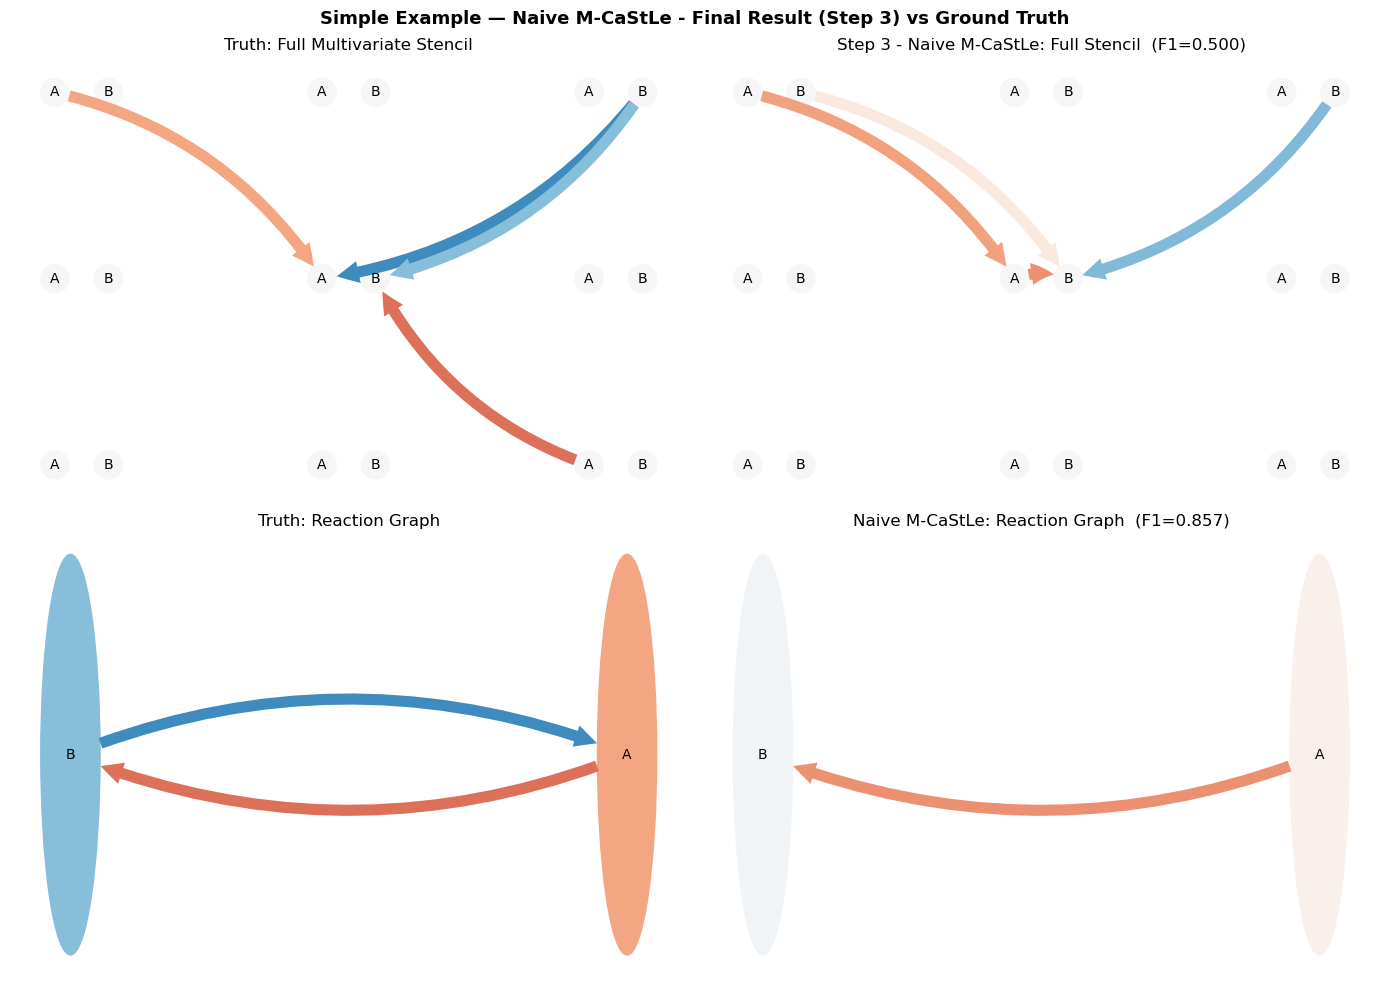

In [31]:
plot_final_comparison(
    true_stencil0, true_vals0,
    disc_stencil0, disc_vals0,
    var_names=["A", "B"],
    f1_stencil=f1_full0,
    f1_rx=f1_rx0,
    title_prefix="Simple Example — ",
)
plt.show()

---
## Experiment 1: 2 Variables, 4×4 Grid, 0.5 Link Density

With 2 variables and 0.5 density there are ≈18 non-zero links in the full stencil (out of 36 possible: 9 positions × 2² variable-pairs). About half of these will be intra-variable spatial links (which U-CaStLe can recover) and half will be cross-variable links from a spatial neighbor of one variable to the center of another (only the center-to-center subset is recoverable by the naive method).

The F1 score will reflect this partial recovery. We expect:
- ✅ Good recall on intra-variable spatial links (diagonal stencil blocks)
- ⚠️ Partial recall on cross-variable links — only center→center are discoverable
- The FDR measures how many discovered links are false positives

### 1.1 Generate Data

In [ ]:
T1          = 500
grid_size1  = 4
n_vars1     = 2
density1    = 0.5
min_coef1   = 0.1  # minimum coefficient magnitude

spatial_coefs1, data1 = dg.generate_dataset(
    T=T1,
    grid_size=grid_size1,
    num_variables=n_vars1,
    dependence_density=density1,
    coefficient_min_value_threshold=min_coef1,
    return_coefs=True,
    random_seed=42,
    verbose=0,
)

print(f"spatial_coefs1 shape : {spatial_coefs1.shape}  (n_vars, 3, 3)")
print(f"data1 shape          : {data1.shape}  (n_vars, X, Y, T)")

# Count non-zero links (spatial_coefs is an object array whose elements are sub-arrays)
n_true_links1 = sum(
    np.count_nonzero(spatial_coefs1[c, i, j])
    for c in range(n_vars1) for i in range(3) for j in range(3)
)
print(f"True non-zero coefficients (links): {n_true_links1}")
print(f"Effective density: {dg.get_density(n_true_links1, n_vars1):.3f}")

### 1.2 Ground-Truth Stencil

True stencil shape: (18, 18, 2)  — (9*N, 9*N, 2) = (9*2, 9*2, 2)
True links (graph != ''): 18


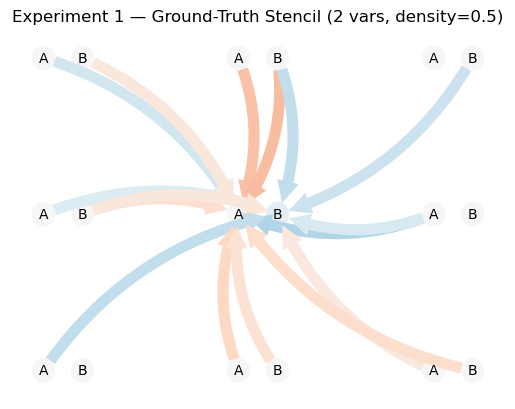

In [ ]:
true_stencil1, true_vals1 = mcastle.get_stencil_graph_from_coefficients(spatial_coefs1)
print(f"True stencil shape: {true_stencil1.shape}  — (9*N, 9*N, 2) = (9*{n_vars1}, 9*{n_vars1}, 2)")
print(f"True links (graph != ''): {int(np.sum(true_stencil1 != ''))}")

fig, ax = mcastle.plot_stencil_graph(
    stencil_graph=true_stencil1,
    stencil_val_matrix=true_vals1,
    var_names=["A", "B"],
)
ax.set_title("Experiment 1 — Ground-Truth Stencil (2 vars, density=0.5)")
plt.show()

### 1.3 Run Naive M-CaStLe

`naive_mv_CaStLe_PC` runs U-CaStLe on each variable independently and then combines with a non-spatial PC run on spatially-aggregated timeseries.

In [ ]:
ci_test1 = ParCorr(significance="analytic")

naive_results1 = naive_mv_CaStLe_PC(
    data=data1,
    cond_ind_test=ci_test1,
    pc_alpha=0.05,
    graph_p_threshold=0.05,
    min_tau=1,
    rows_inverted=True,
    cd_function="run_pcalg",
    fdr_method="bh",
    dependencies_wrap=True,
    allow_center_directed_links=True,
    verbose=1,
)

disc_stencil1 = naive_results1["graph"]
disc_vals1    = naive_results1["val_matrix"]
print(f"\nDiscovered stencil shape: {disc_stencil1.shape}")
print(f"Discovered links (graph != ''): {int(np.sum(disc_stencil1 != ''))}")

Running U-CaStLe on variable 0 of 2...
Running U-CaStLe on variable 1 of 2...
Running non-spatial run_pcalg on spatially aggregated data (shape (500, 2))...
Naive multivariate stencil assembled.

Discovered stencil shape: (18, 18, 2)
Discovered links (graph != ''): 11


### 1.4 F1 Scores

We score the full `(9*N, 9*N, 2)` stencil, plus the per-variable intra-stencils and the reaction graph separately, to see where the naive method succeeds and fails.

In [ ]:
# --- Full multivariate stencil ---
print("=" * 55)
f1_full1, *_ = print_f1_report("Full stencil  (9*N x 9*N x 2)", true_stencil1, disc_stencil1)

# --- Per-variable intra-stencil (diagonal blocks only) ---
print()
for k, vname in enumerate(["A", "B"]):
    bs = 9 * k; be = bs + 9
    print_f1_report(f"Intra-variable block  var={vname}",
                    true_stencil1[bs:be, bs:be, :], disc_stencil1[bs:be, bs:be, :])

# --- Reaction graph ---
print()
true_rx1, true_rx_val1, _, _ = mcastle.analyze_stencil_graphs(true_stencil1, true_vals1)
disc_rx1, disc_rx_val1, _, _ = mcastle.analyze_stencil_graphs(disc_stencil1, disc_vals1)
f1_rx1, *_ = print_f1_report("Reaction graph  (N x N x 2)", true_rx1, disc_rx1)
print("=" * 55)

Full stencil  (9*N x 9*N x 2)
  F1=0.414  Precision=0.545  Recall=0.333  MCC=0.414  FDR=0.455
  TP=6  FP=5  FN=12  TN=625

Intra-variable block  var=A
  F1=1.000  Precision=1.000  Recall=1.000  MCC=1.000  FDR=0.000
  TP=4  FP=0  FN=0  TN=158
Intra-variable block  var=B
  F1=0.200  Precision=0.167  Recall=0.250  MCC=0.179  FDR=0.833
  TP=1  FP=5  FN=3  TN=153

Reaction graph  (N x N x 2)
  F1=0.857  Precision=1.000  Recall=0.750  MCC=0.775  FDR=0.000
  TP=3  FP=0  FN=1  TN=4


### 1.5 Visual Comparison

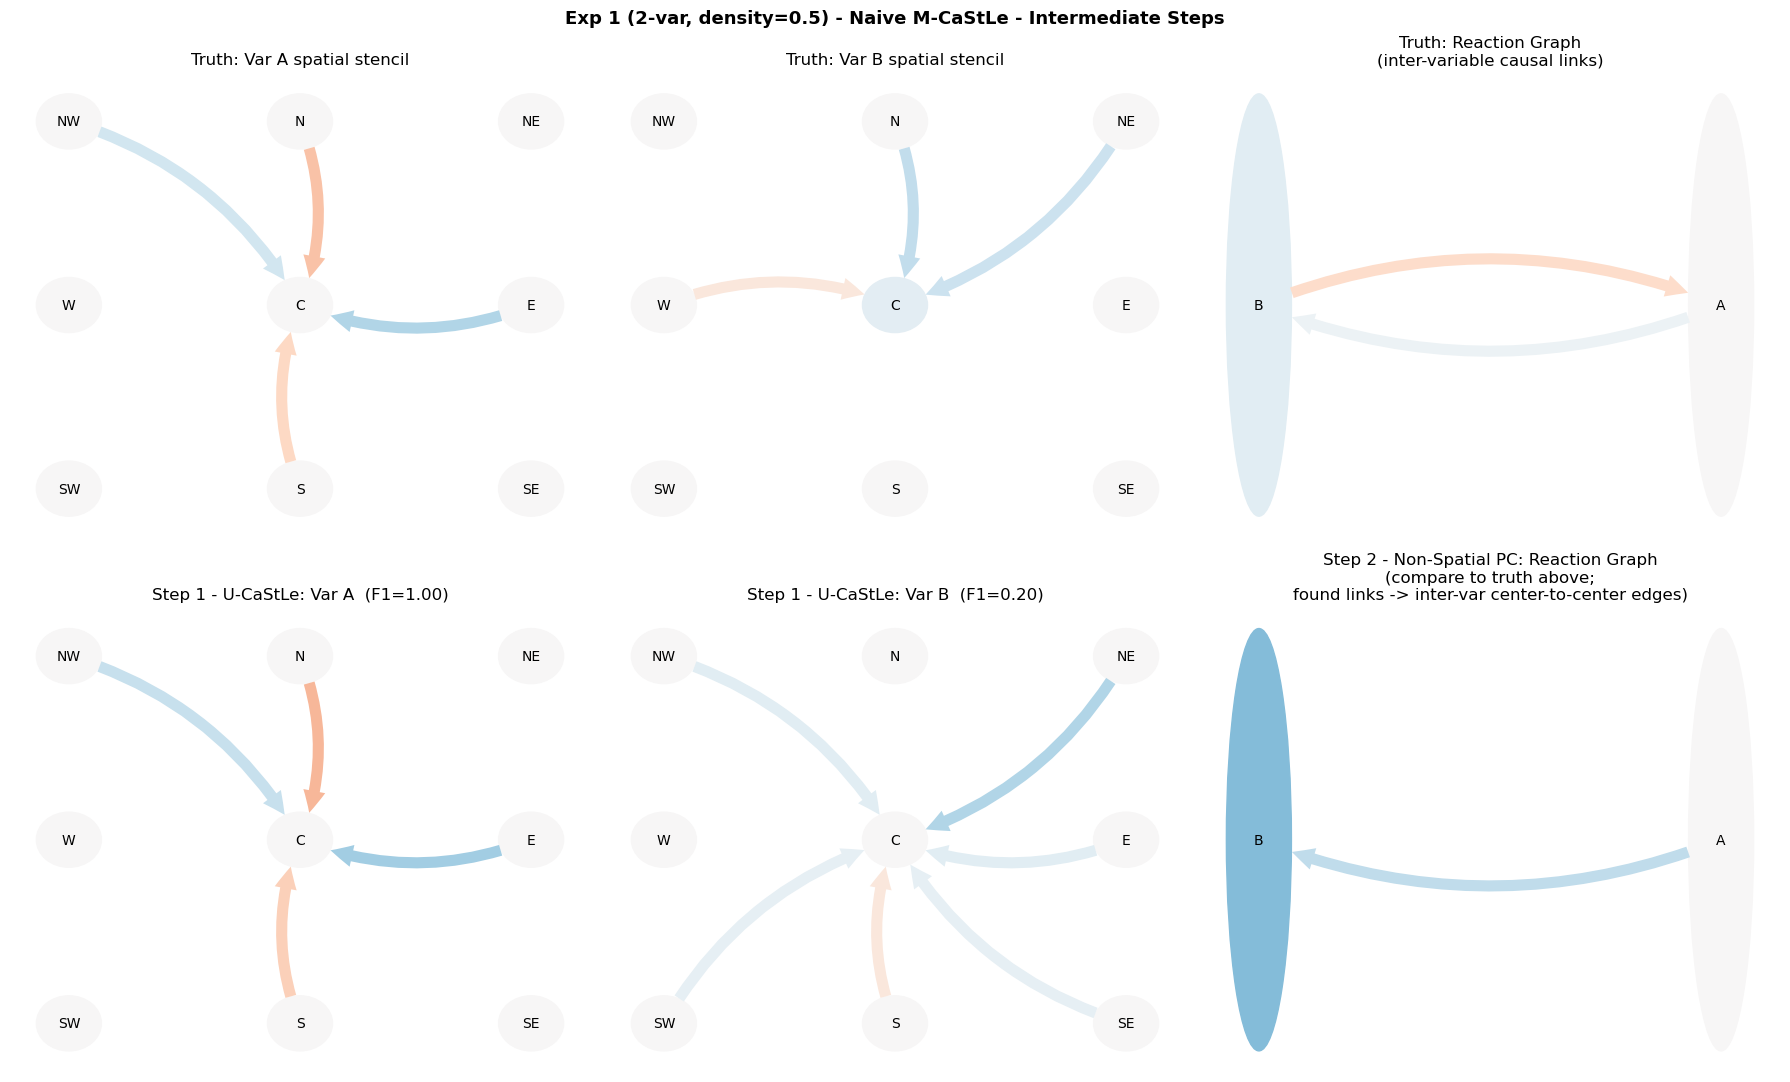

In [ ]:
plot_intermediate_steps(
    true_stencil1, true_vals1,
    naive_results1,
    var_names=["A", "B"],
    title_prefix="Exp 1 (2-var, density=0.5) - ",
)
plt.show()

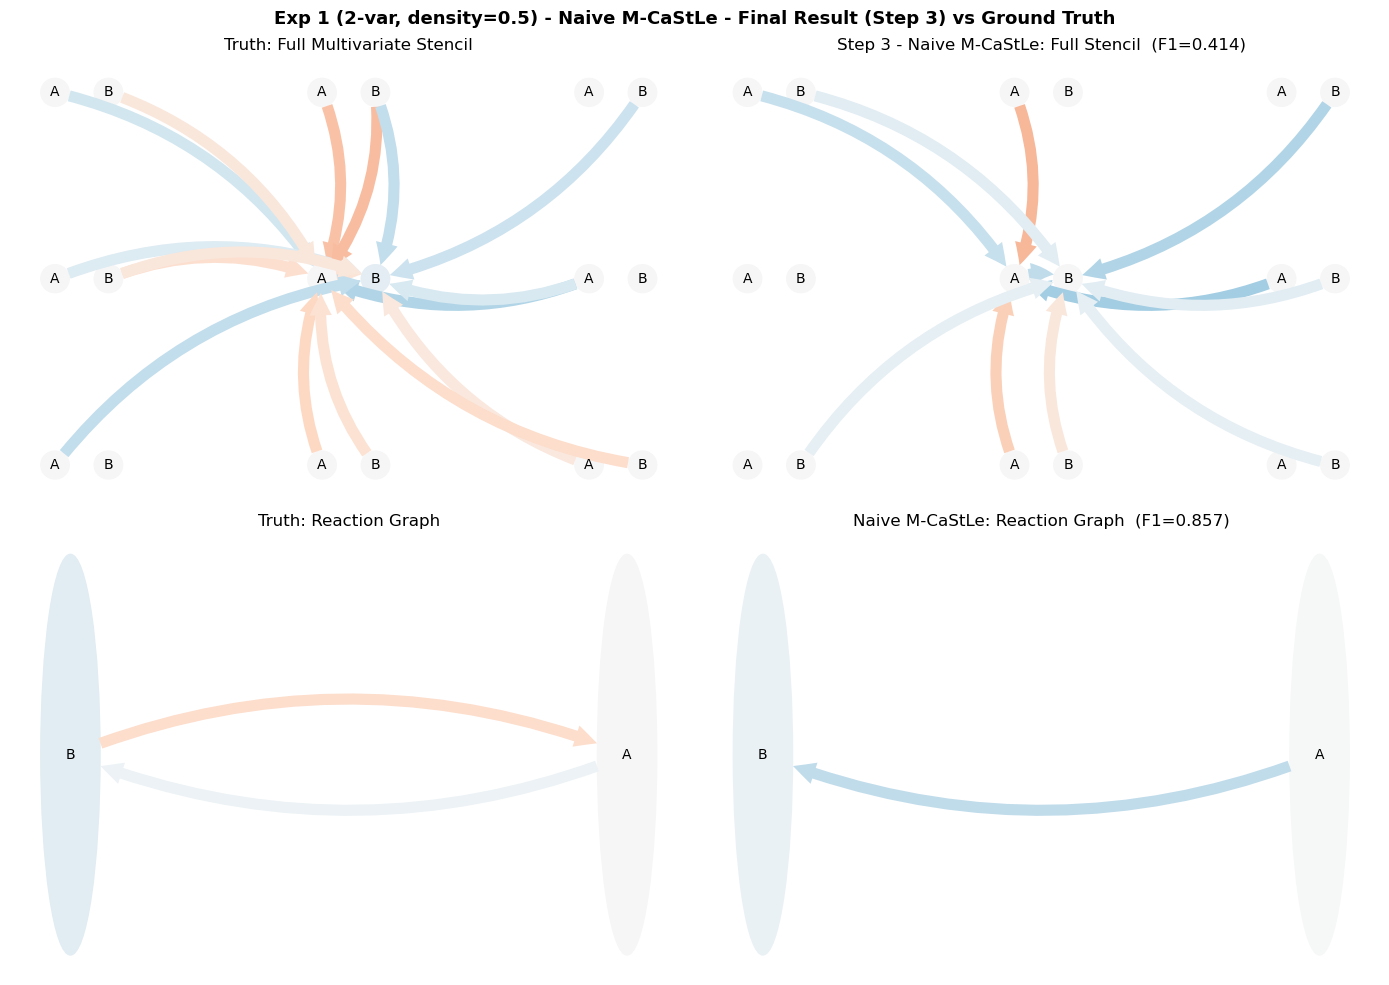

In [ ]:
plot_final_comparison(
    true_stencil1, true_vals1,
    disc_stencil1, disc_vals1,
    var_names=["A", "B"],
    f1_stencil=f1_full1,
    f1_rx=f1_rx1,
    title_prefix="Exp 1 (2-var, density=0.5) - ",
)
plt.show()

---
## Experiment 2: 4 Variables, 4×4 Grid, 15 Links

With 4 variables, the full stencil has 9 × 4² = 144 possible links. Requesting 15 links gives density ≈ 0.10 — a sparse system. At this sparsity the method is less likely to encounter dense cross-variable spatial structure, making the center-to-center approximation more accurate.

We expect:
- ✅ Good intra-variable stencil recovery (diagonal blocks) — same as the 2-variable case  
- ✅ Better inter-variable F1 than Experiment 1 because sparser cross-variable links are less likely to land on off-center positions  
- The full-stencil F1 provides the aggregate picture

### 2.1 Generate Data

In [ ]:
T2         = 500
grid_size2 = 4
n_vars2    = 4
num_links2 = 15
min_coef2  = 0.1

spatial_coefs2, data2 = dg.generate_dataset(
    T=T2,
    grid_size=grid_size2,
    num_variables=n_vars2,
    num_links=num_links2,
    coefficient_min_value_threshold=min_coef2,
    return_coefs=True,
    random_seed=7,
    verbose=0,
)

print(f"spatial_coefs2 shape : {spatial_coefs2.shape}  (n_vars, 3, 3)")
print(f"data2 shape          : {data2.shape}  (n_vars, X, Y, T)")

# Count non-zero links (spatial_coefs is an object array whose elements are sub-arrays)
n_true_links2 = sum(
    np.count_nonzero(spatial_coefs2[c, i, j])
    for c in range(n_vars2) for i in range(3) for j in range(3)
)
print(f"True non-zero coefficients (links): {n_true_links2}")
print(f"Effective density: {dg.get_density(n_true_links2, n_vars2):.4f}")

### 2.2 Ground-Truth Stencil

True stencil shape : (36, 36, 2)  (9*4, 9*4, 2)
True links         : 15


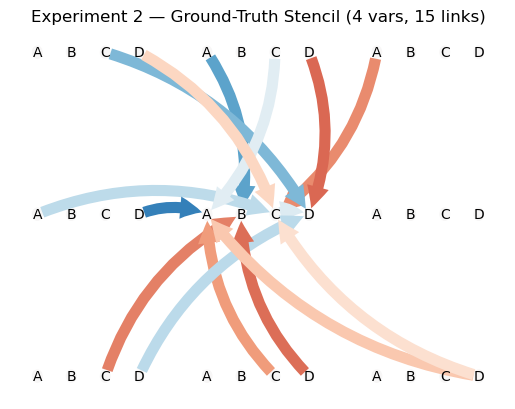

In [ ]:
var_names2 = ["A", "B", "C", "D"]

true_stencil2, true_vals2 = mcastle.get_stencil_graph_from_coefficients(spatial_coefs2)
print(f"True stencil shape : {true_stencil2.shape}  (9*{n_vars2}, 9*{n_vars2}, 2)")
print(f"True links         : {int(np.sum(true_stencil2 != ''))}")

fig, ax = mcastle.plot_stencil_graph(
    stencil_graph=true_stencil2,
    stencil_val_matrix=true_vals2,
    var_names=var_names2,
)
ax.set_title("Experiment 2 — Ground-Truth Stencil (4 vars, 15 links)")
plt.show()

### 2.3 Run Naive M-CaStLe

In [ ]:
ci_test2 = ParCorr(significance="analytic")

naive_results2 = naive_mv_CaStLe_PC(
    data=data2,
    cond_ind_test=ci_test2,
    pc_alpha=0.05,
    graph_p_threshold=0.05,
    min_tau=1,
    rows_inverted=True,
    cd_function="run_pcalg",
    fdr_method="bh",
    dependencies_wrap=True,
    allow_center_directed_links=True,
    verbose=1,
)

disc_stencil2 = naive_results2["graph"]
disc_vals2    = naive_results2["val_matrix"]
print(f"\nDiscovered stencil shape : {disc_stencil2.shape}")
print(f"Discovered links         : {int(np.sum(disc_stencil2 != ''))}")

Running U-CaStLe on variable 0 of 4...
Running U-CaStLe on variable 1 of 4...
Running U-CaStLe on variable 2 of 4...
Running U-CaStLe on variable 3 of 4...
Running non-spatial run_pcalg on spatially aggregated data (shape (500, 4))...
Naive multivariate stencil assembled.

Discovered stencil shape : (36, 36, 2)
Discovered links         : 5


### 2.4 F1 Scores

In [ ]:
print("=" * 60)
f1_full2, *_ = print_f1_report("Full stencil  (9*N x 9*N x 2)", true_stencil2, disc_stencil2)

print()
for k, vname in enumerate(var_names2):
    bs = 9*k; be = bs+9
    print_f1_report(f"Intra-variable block  var={vname}",
                    true_stencil2[bs:be, bs:be, :], disc_stencil2[bs:be, bs:be, :])

print()
true_rx2, true_rx_val2, _, _ = mcastle.analyze_stencil_graphs(true_stencil2, true_vals2)
disc_rx2, disc_rx_val2, _, _ = mcastle.analyze_stencil_graphs(disc_stencil2, disc_vals2)
f1_rx2, *_ = print_f1_report("Reaction graph  (N x N x 2)", true_rx2, disc_rx2)
print("=" * 60)

Full stencil  (9*N x 9*N x 2)
  F1=0.300  Precision=0.600  Recall=0.200  MCC=0.344  FDR=0.400
  TP=3  FP=2  FN=12  TN=2575

Intra-variable block  var=A
  F1=1.000  Precision=1.000  Recall=1.000  MCC=1.000  FDR=0.000
  TP=0  FP=0  FN=0  TN=162
Intra-variable block  var=B
  F1=1.000  Precision=1.000  Recall=1.000  MCC=1.000  FDR=0.000
  TP=0  FP=0  FN=0  TN=162
Intra-variable block  var=C
  F1=1.000  Precision=1.000  Recall=1.000  MCC=1.000  FDR=0.000
  TP=0  FP=0  FN=0  TN=162
Intra-variable block  var=D
  F1=1.000  Precision=1.000  Recall=1.000  MCC=1.000  FDR=0.000
  TP=2  FP=0  FN=0  TN=160

Reaction graph  (N x N x 2)
  F1=0.615  Precision=1.000  Recall=0.444  MCC=0.604  FDR=0.000
  TP=4  FP=0  FN=5  TN=23


### 2.5 Visual Comparison

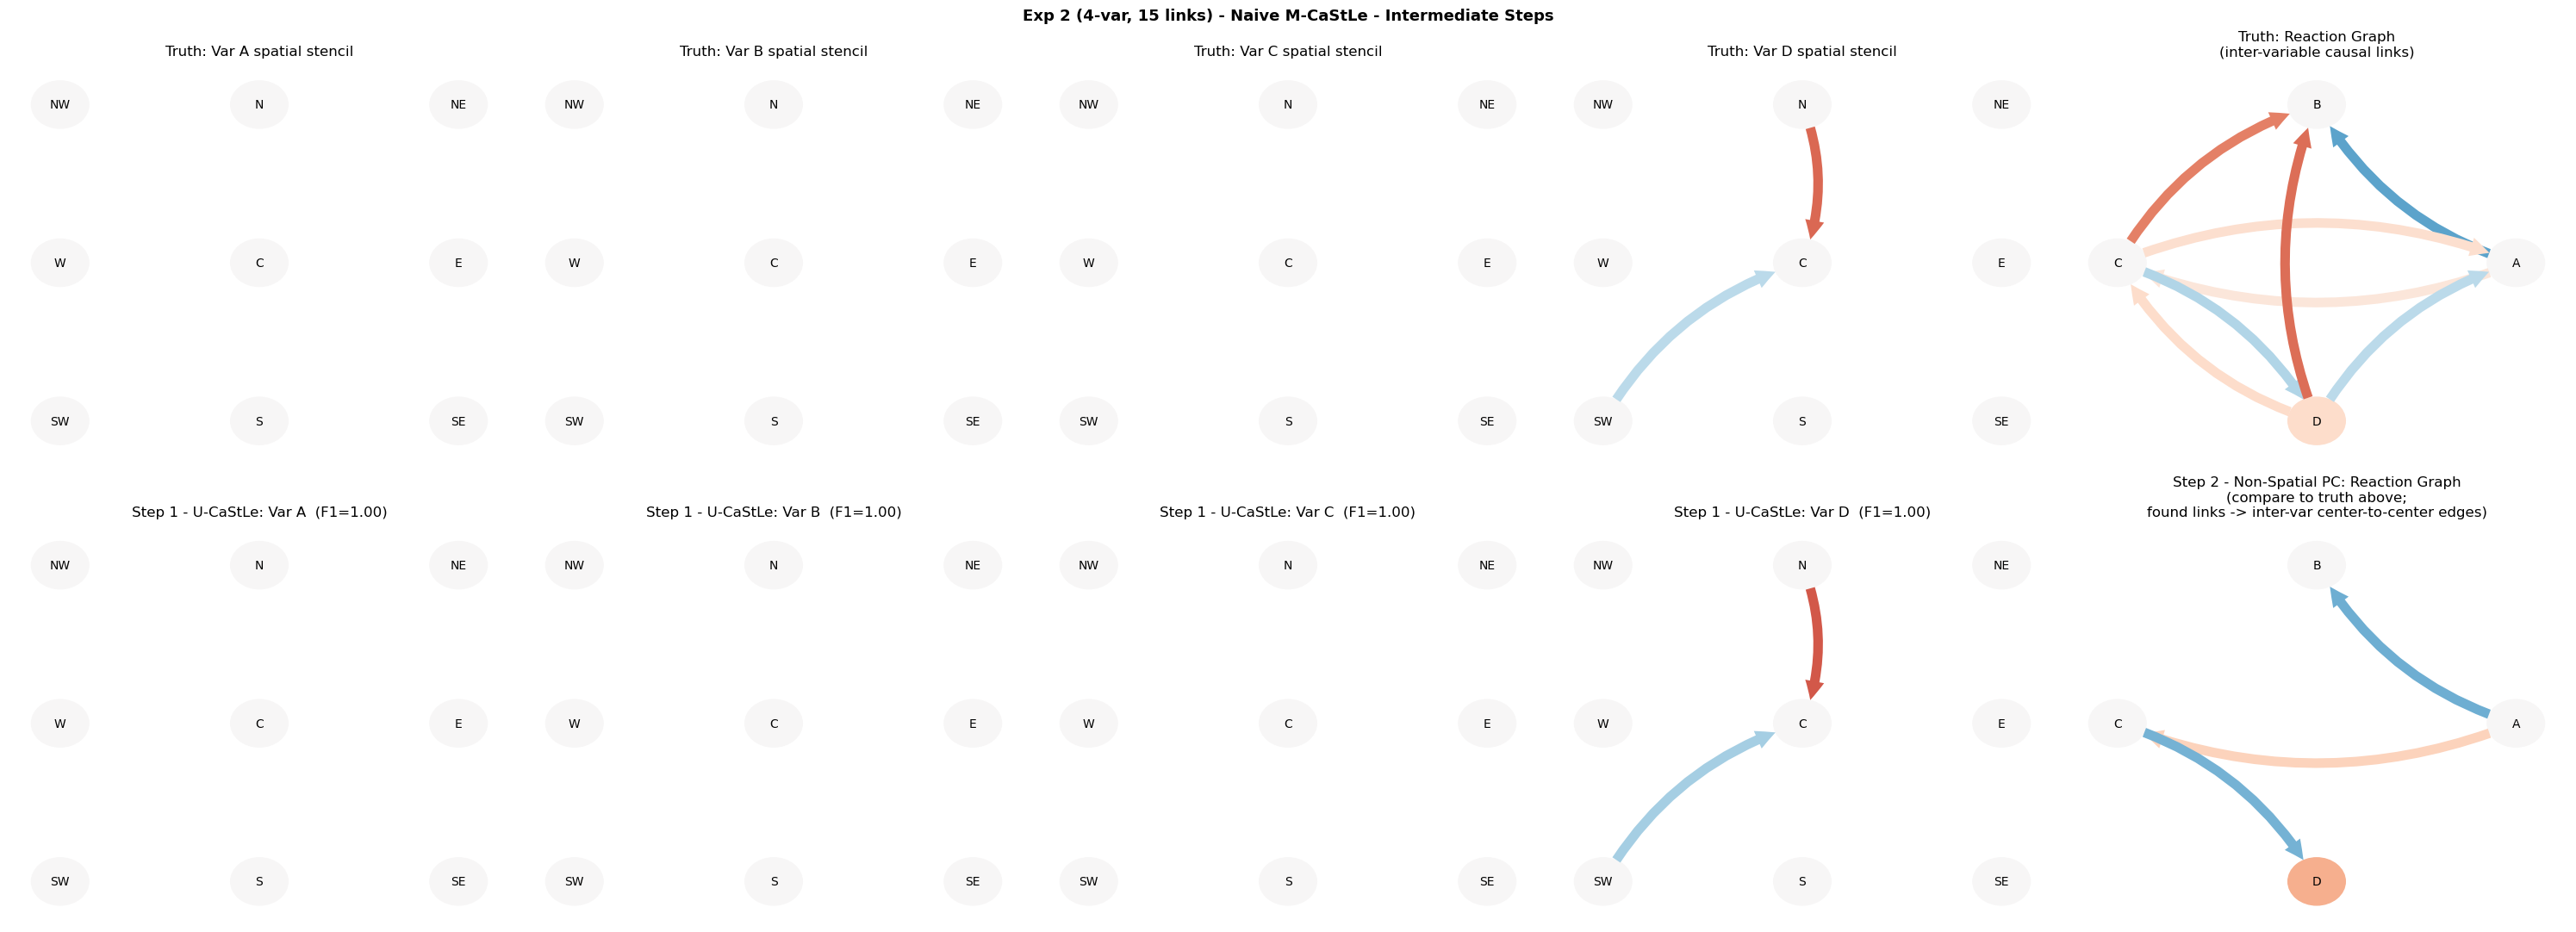

In [ ]:
plot_intermediate_steps(
    true_stencil2, true_vals2,
    naive_results2,
    var_names=var_names2,
    title_prefix="Exp 2 (4-var, 15 links) - ",
)
plt.show()

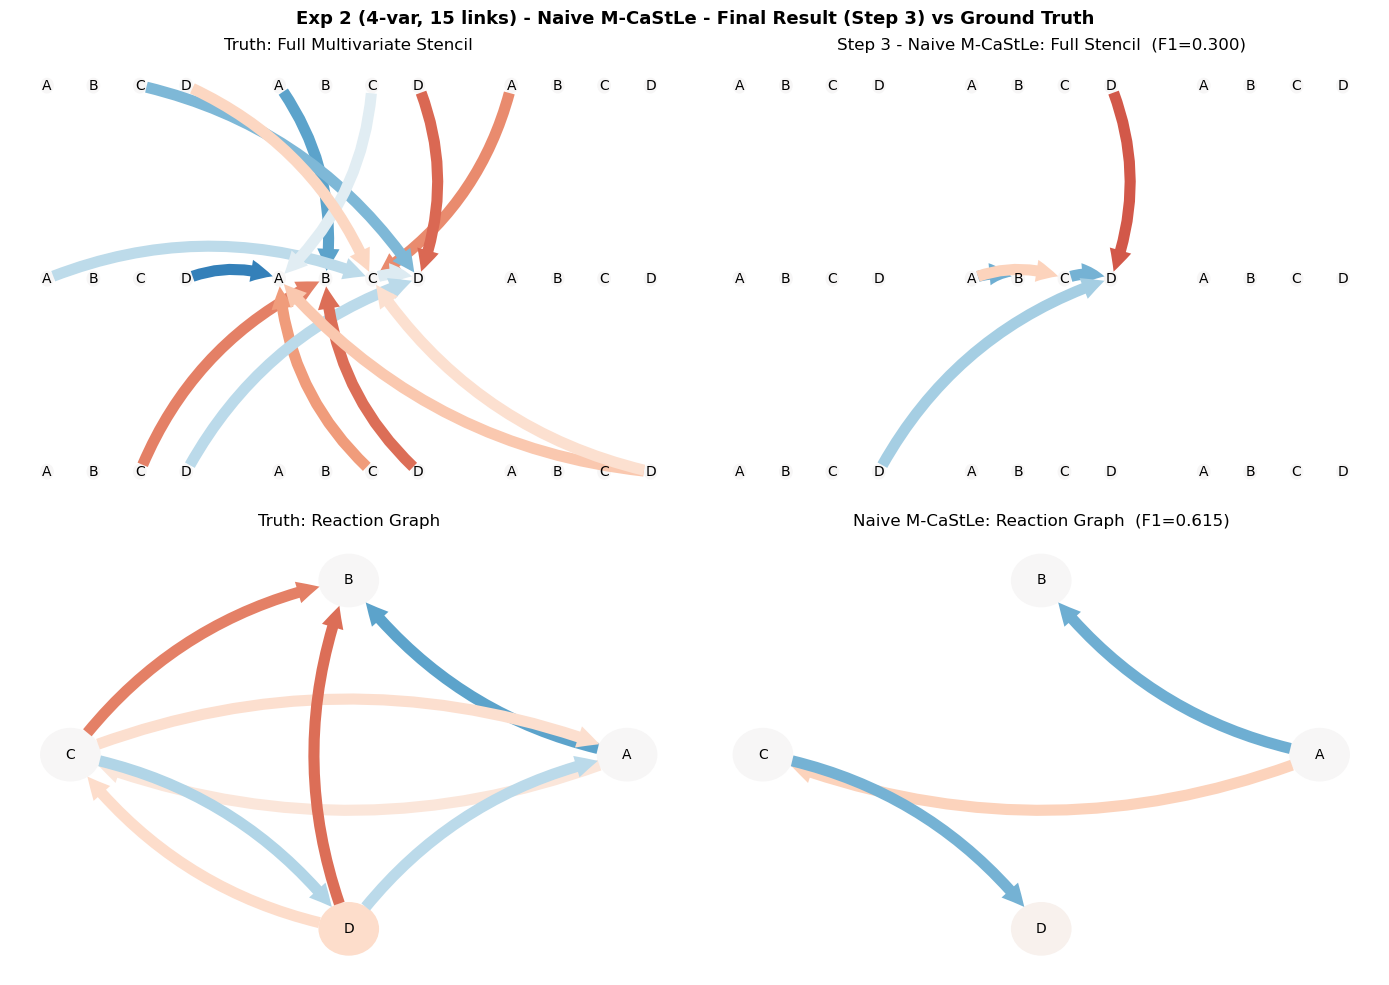

In [ ]:
plot_final_comparison(
    true_stencil2, true_vals2,
    disc_stencil2, disc_vals2,
    var_names=var_names2,
    f1_stencil=f1_full2,
    f1_rx=f1_rx2,
    title_prefix="Exp 2 (4-var, 15 links) - ",
)
plt.show()

---
## Summary

Compare performance across both experiments.

In [ ]:
import pandas as pd

rows = []
for label, true_s, disc_s, true_rx, disc_rx, n_true_lnk in [
    ("Exp 1 — 2 vars density=0.5", true_stencil1, disc_stencil1, true_rx1, disc_rx1, n_true_links1),
    ("Exp 2 — 4 vars 15 links",    true_stencil2, disc_stencil2, true_rx2, disc_rx2, n_true_links2),
]:
    TP, FP, FN, TN = gm.get_confusion_matrix(true_s, disc_s)
    F1, P, R, *_   = gm.F1_score(TP=TP, FP=FP, FN=FN, TN=TN)
    MCC = gm.matthews_correlation_coefficient(TP=TP, FP=FP, FN=FN, TN=TN)
    FDR = gm.false_discovery_rate(FP, TP)

    TP_rx, FP_rx, FN_rx, TN_rx = gm.get_confusion_matrix(true_rx, disc_rx)
    F1_rx, P_rx, R_rx, *_       = gm.F1_score(TP=TP_rx, FP=FP_rx, FN=FN_rx, TN=TN_rx)

    rows.append({
        "Experiment":         label,
        "True links":         n_true_lnk,
        "Stencil F1":         round(F1, 3),
        "Stencil Precision":  round(P, 3),
        "Stencil Recall":     round(R, 3),
        "Stencil MCC":        round(MCC, 3),
        "Stencil FDR":        round(FDR, 3),
        "Reaction F1":        round(F1_rx, 3),
    })

df = pd.DataFrame(rows).set_index("Experiment")
print(df.to_string())
df

                            True links  Stencil F1  Stencil Precision  Stencil Recall  Stencil MCC  Stencil FDR  Reaction F1
Experiment                                                                                                                  
Exp 1 — 2 vars density=0.5           1       0.414              0.545           0.333        0.414        0.455        0.857
Exp 2 — 4 vars 15 links              1       0.300              0.600           0.200        0.344        0.400        0.615


,True links,Stencil F1,Stencil Precision,Stencil Recall,Stencil MCC,Stencil FDR,Reaction F1
Experiment,,,,,,,
Exp 1 — 2 vars density=0.5,1,0.414,0.545,0.333,0.414,0.455,0.857
Exp 2 — 4 vars 15 links,1,0.300,0.600,0.200,0.344,0.400,0.615


### Interpretation

| Score | What it tells you |
|-------|-------------------|
| **Stencil F1** | Overall precision/recall of the full `(9N×9N×2)` graph — penalised for every missed or spurious link at any spatial position. |
| **Reaction F1** | Variable-level F1 after collapsing the stencil to an `(N×N×2)` reaction graph. A high reaction F1 with lower stencil F1 shows that the naive method correctly identifies *which* variables interact, but gets the spatial position of the link wrong. |
| **FDR** | Fraction of discovered links that are false positives. |

**Key limitation visible in these results:** The naive method recovers intra-variable spatial stencils well (diagonal blocks, via U-CaStLe) and can identify the presence of inter-variable interactions (via non-spatial PC, visible in the reaction graph). However, it always places those inter-variable links at the center-to-center position, which is incorrect whenever the true coupling involves off-center spatial positions — a gap that M-CaStLe fills by treating all variables jointly in the reduced neighborhood space.